# Daily S&P 500 Return Prediction — Regression Models

Attempt to predict the **next-day SPY return** from the same-day returns of 12 large index constituents.
We compare three models (XGBoost, LightGBM, Transformer), each evaluated with walk-forward validation against a trivial baseline.

## Imports and environment setup

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, mean_absolute_error
import xgboost as xgb
from sklearn.model_selection import train_test_split
import lightgbm as lgb
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["MKL_THREADING_LAYER"] = "GNU"
torch.set_num_threads(1)

sns.set_theme(style="whitegrid")

## Data loading
12 large-cap tickers as features, SPY as the target.

In [2]:
core_stocks = ["aapl", "msft", "googl", "amzn", "nvda", "jpm", "bac", "gs", "xom", "gld", "jnj", "ko"]  
data_path = "Data_clean/Stocks clean"
sp500_path = "Data_clean/ETF clean/spy_clean.csv"
combined_df = pd.DataFrame()

In [3]:
# Load each ticker's closing price into a single combined table (one column per stock)
for ticker in core_stocks:
    file_path = os.path.join(data_path, f"{ticker}_clean.csv")
    temp_df = pd.read_csv(file_path, index_col="Date", parse_dates=True)
    combined_df[ticker] = temp_df["Close"]

# Add SPY closing price as the prediction target
sp500_df = pd.read_csv(sp500_path, index_col="Date", parse_dates=True)

df = combined_df.copy()
df["spy"] = sp500_df["Close"]

In [4]:
df = df.sort_index()

# Trim to the common date range where all tickers have data
start_date = '2005-02-25'
df = df.loc[start_date:]

df.head()

,aapl,msft,googl,amzn,nvda,jpm,bac,gs,xom,gld,jnj,ko,spy
Date,,,,,,,,,,,,,
2005-02-25,5.6975,21.173,92.935,34.99,8.9161,30.812,44.109,100.420,50.892,43.50,53.894,17.546,105.79
2005-02-28,5.7449,21.099,93.995,35.18,8.9625,30.463,43.980,99.241,50.937,43.52,53.390,17.456,105.08
2005-03-01,5.6987,21.199,93.030,35.39,8.9439,30.911,44.384,100.350,49.964,43.22,54.244,17.649,105.62
2005-03-02,5.6499,21.182,92.590,35.50,8.6843,30.828,43.904,100.090,50.433,43.25,54.496,17.555,105.57
2005-03-03,5.3518,21.109,93.505,35.65,8.5635,30.847,43.680,99.790,50.735,42.97,54.324,17.611,105.61


## Features and target

Features: same-day percentage returns of the 12 stocks.
Target: **next-day** SPY return — `shift(-1)` moves tomorrow's return onto today's row, so we predict the future from the present (no look-ahead leakage).

In [5]:
# Features: same-day returns of the 12 stocks
returns_df = df[core_stocks].pct_change()

# Target: next-day SPY return. shift(-1) aligns tomorrow's return with today's features,
# so the model predicts the future from the present (no look-ahead leakage).
returns_df['spy'] = df['spy'].pct_change().shift(-1)

returns_df = returns_df.loc["2005-02-28":]  # drop the first row (NaN from pct_change)
returns_df = returns_df.dropna()            # drop the last row (NaN from shift(-1))
returns_df.head()

,aapl,msft,googl,amzn,nvda,jpm,bac,gs,xom,gld,jnj,ko,spy
Date,,,,,,,,,,,,,
2005-02-28,0.008319,-0.003495,0.011406,0.005430,0.005204,-0.011327,-0.002925,-0.011741,0.000884,0.000460,-0.009352,-0.005129,0.005139
2005-03-01,-0.008042,0.004740,-0.010267,0.005969,-0.002075,0.014706,0.009186,0.011175,-0.019102,-0.006893,0.015996,0.011056,-0.000473
2005-03-02,-0.008563,-0.000802,-0.004730,0.003108,-0.029025,-0.002685,-0.010815,-0.002591,0.009387,0.000694,0.004646,-0.005326,0.000379
2005-03-03,-0.052762,-0.003446,0.009882,0.004225,-0.013910,0.000616,-0.005102,-0.002997,0.005988,-0.006474,-0.003156,0.003190,0.012499
2005-03-04,0.024384,0.000000,-0.005936,0.005610,-0.004356,0.013453,0.009615,0.019341,0.008121,0.009542,0.014837,0.010732,0.000374


## Train/test split

Time-ordered split (`shuffle=False`) — train on the past, test on the future.
Shuffling would leak future information into training and inflate the results.
Then we do a TimeSeriesSplit.

In [6]:
X = returns_df[core_stocks]
y = returns_df["spy"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, shuffle = False)

In [7]:
tscv = TimeSeriesSplit(n_splits=5)
X_all = X.values
y_all = y.values

In [8]:
# Baseline 1: always predict zero (no information assumed → expected return = 0)
mae_baseline_zero = mean_absolute_error(y_test, np.zeros_like(y_test))

# Baseline 2: always predict the training-set mean return
mae_baseline_mean = mean_absolute_error(y_test, np.full_like(y_test, y_train.mean()))

print(f"Baseline MAE (zero):  {mae_baseline_zero:.6f}")
print(f"Baseline MAE (mean):  {mae_baseline_mean:.6f}")

Baseline MAE (zero):  0.005130
Baseline MAE (mean):  0.005116


## XGBoost (walk-forward)

Gradient-boosted trees on the 12 same-day returns. A fresh model is trained on each fold,
with the baseline computed **within the same fold** so the comparison is fair across periods of different volatility.

In [9]:
xgb_mae, xgb_base = [], []
for fold, (tr, te) in enumerate(tscv.split(X), start=1):
    X_tr, X_te = X.iloc[tr], X.iloc[te]
    y_tr, y_te = y.iloc[tr], y.iloc[te]
    m = xgb.XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42)
    m.fit(X_tr, y_tr)
    mae = mean_absolute_error(y_te, m.predict(X_te))
    base = mean_absolute_error(y_te, np.zeros_like(y_te))
    xgb_mae.append(mae); xgb_base.append(base)
    print(f"Fold {fold}:  MAE={mae:.6f}  |  baseline={base:.6f}  |  improvement={base - mae:+.6f}")
print(f"\nXGB walk-forward:  mean MAE={np.mean(xgb_mae):.6f}  mean improvement={np.mean(xgb_base) - np.mean(xgb_mae):+.6f}")

Fold 1:  MAE=0.013874  |  baseline=0.013638  |  improvement=-0.000236
Fold 2:  MAE=0.007607  |  baseline=0.007397  |  improvement=-0.000210
Fold 3:  MAE=0.007662  |  baseline=0.007518  |  improvement=-0.000145
Fold 4:  MAE=0.005706  |  baseline=0.005626  |  improvement=-0.000080
Fold 5:  MAE=0.004784  |  baseline=0.004689  |  improvement=-0.000094

XGB walk-forward:  mean MAE=0.007927  mean improvement=-0.000153


In [10]:
# Single-split reference for comparison with the walk-forward result above
# (one split = one number; walk-forward is the more reliable estimate)
model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print(f"XGBoost MAE:  {mae:.6f}  |  baseline(zero): {mae_baseline_zero:.6f}  |  improvement: {mae_baseline_zero - mae:+.6f}")

XGBoost MAE:  0.005242  |  baseline(zero): 0.005130  |  improvement: -0.000112


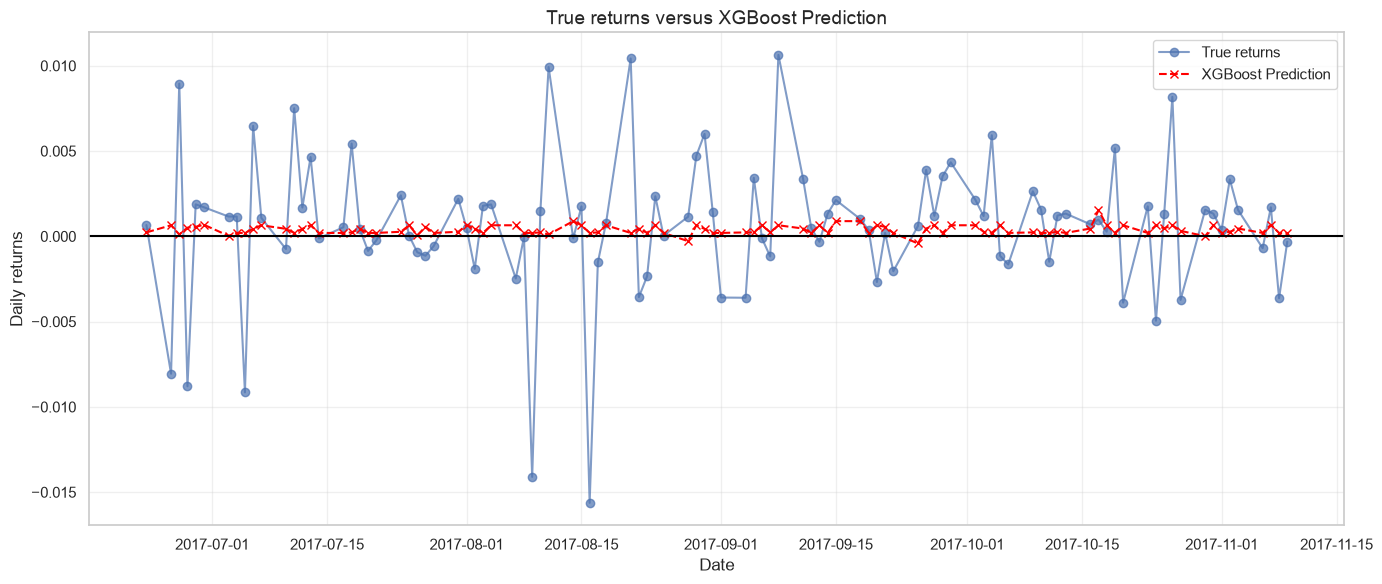

In [11]:
plt.figure(figsize=(14, 6))
last_days = 100
plt.plot(y_test.index[-last_days:], y_test.iloc[-last_days:], 
         label='True returns', marker='o', alpha=0.7)
plt.plot(y_test.index[-last_days:], y_pred[-last_days:], 
         label='XGBoost Prediction', marker='x', linestyle='--', color='red')
plt.title('True returns versus XGBoost Prediction', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Daily returns', fontsize=12)
plt.axhline(0, color='black', linewidth=1.5, linestyle='-') 

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

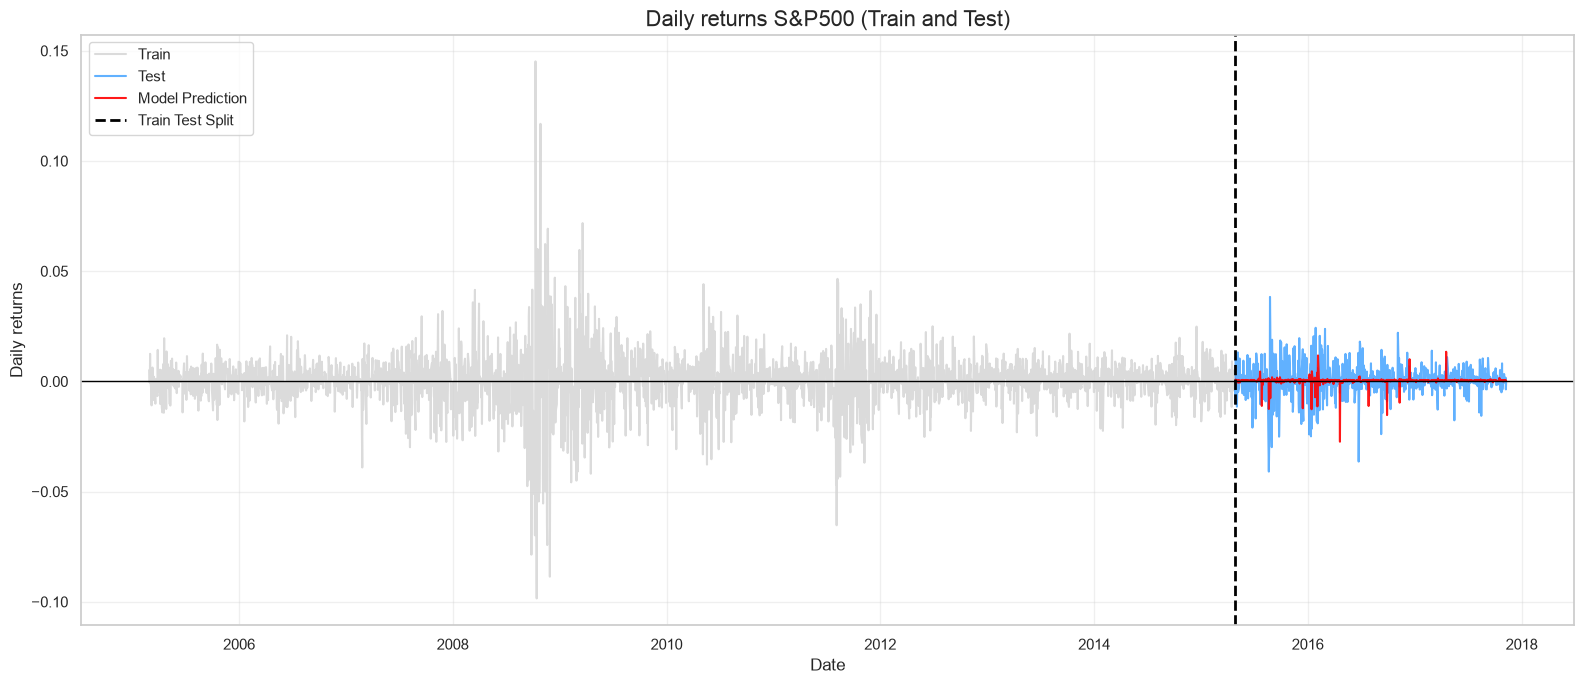

In [12]:
plt.figure(figsize=(16, 7))
plt.plot(y_train.index, y_train, label='Train', color='lightgray', alpha=0.8)
plt.plot(y_test.index, y_test, label='Test', color='dodgerblue', alpha=0.7)
plt.plot(y_test.index, y_pred, label='Model Prediction', color='red', alpha=0.9, linewidth=1.5)
plt.axvline(x=y_test.index[0], color='black', linestyle='--', linewidth=2, label='Train Test Split')
plt.axhline(0, color='black', linewidth=1)
plt.title('Daily returns S&P500 (Train and Test)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Daily returns', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The prediction (red) stays flat near zero while true returns swing by ±1.5% — the model collapses to the mean, confirming there is no exploitable signal.

## LightGBM (walk-forward)

Same setup as XGBoost — another gradient-boosting library, used here as a cross-check that the result isn't specific to one implementation.

In [13]:
lgbm_mae, lgbm_base = [], []
for fold, (tr, te) in enumerate(tscv.split(X), start=1):
    X_tr, X_te = X.iloc[tr], X.iloc[te]
    y_tr, y_te = y.iloc[tr], y.iloc[te]

    # num_leaves is LightGBM's main complexity control; kept small to avoid overfitting
    m = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.05, num_leaves=8, max_depth=3, random_state=42, verbose=-1)
    m.fit(X_tr, y_tr)

    mae = mean_absolute_error(y_te, m.predict(X_te))
    base = mean_absolute_error(y_te, np.zeros_like(y_te))
    lgbm_mae.append(mae); lgbm_base.append(base)
    print(f"Fold {fold}:  MAE={mae:.6f}  |  baseline={base:.6f}  |  improvement={base - mae:+.6f}")

print(f"\nLGBM walk-forward:  mean MAE={np.mean(lgbm_mae):.6f}  mean improvement={np.mean(lgbm_base) - np.mean(lgbm_mae):+.6f}")

Fold 1:  MAE=0.013756  |  baseline=0.013638  |  improvement=-0.000117
Fold 2:  MAE=0.007553  |  baseline=0.007397  |  improvement=-0.000155
Fold 3:  MAE=0.007719  |  baseline=0.007518  |  improvement=-0.000201
Fold 4:  MAE=0.005679  |  baseline=0.005626  |  improvement=-0.000053
Fold 5:  MAE=0.004768  |  baseline=0.004689  |  improvement=-0.000078

LGBM walk-forward:  mean MAE=0.007895  mean improvement=-0.000121


In [14]:
# Single-split reference for comparison with the walk-forward result above
# (one split = one number; walk-forward is the more reliable estimate)
model = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.05, num_leaves=8, max_depth=3, random_state=42, verbose=-1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print(f"LightGBM MAE:  {mae:.6f}  |  baseline(zero): {mae_baseline_zero:.6f}  |  improvement: {mae_baseline_zero - mae:+.6f}")

LightGBM MAE:  0.005226  |  baseline(zero): 0.005130  |  improvement: -0.000095


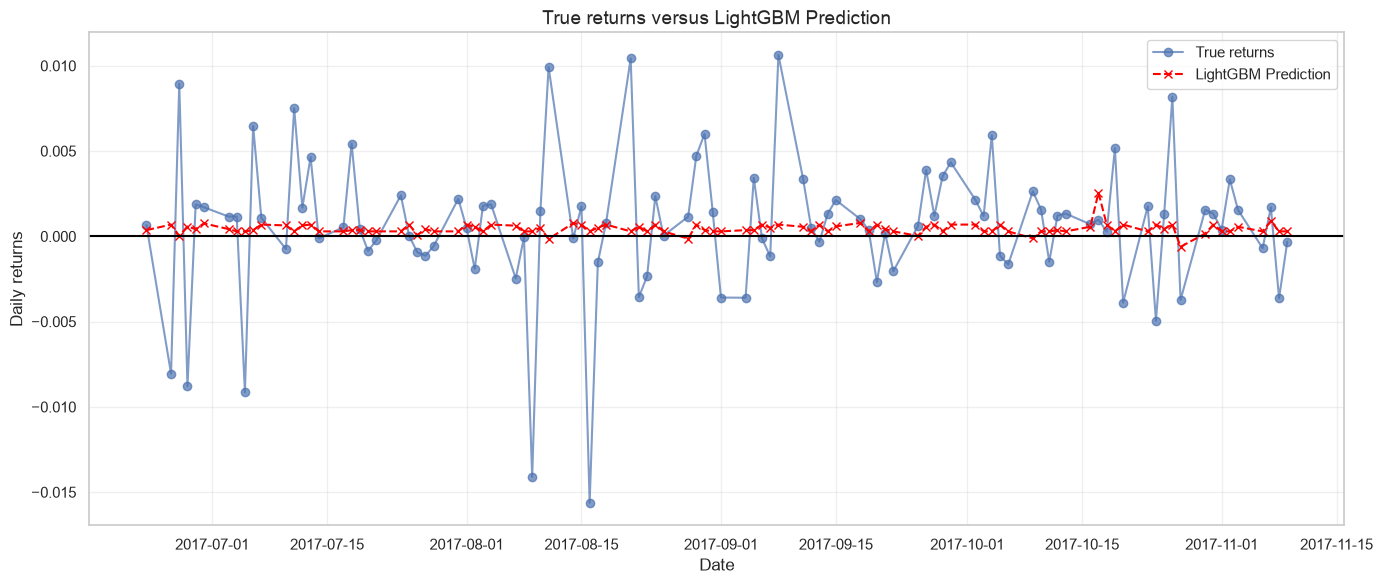

In [15]:
plt.figure(figsize=(14, 6))
last_days = 100
plt.plot(y_test.index[-last_days:], y_test.iloc[-last_days:], 
         label='True returns', marker='o', alpha=0.7)
plt.plot(y_test.index[-last_days:], y_pred[-last_days:], 
         label='LightGBM Prediction', marker='x', linestyle='--', color='red')
plt.title('True returns versus LightGBM Prediction', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Daily returns', fontsize=12)
plt.axhline(0, color='black', linewidth=1.5, linestyle='-') 

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

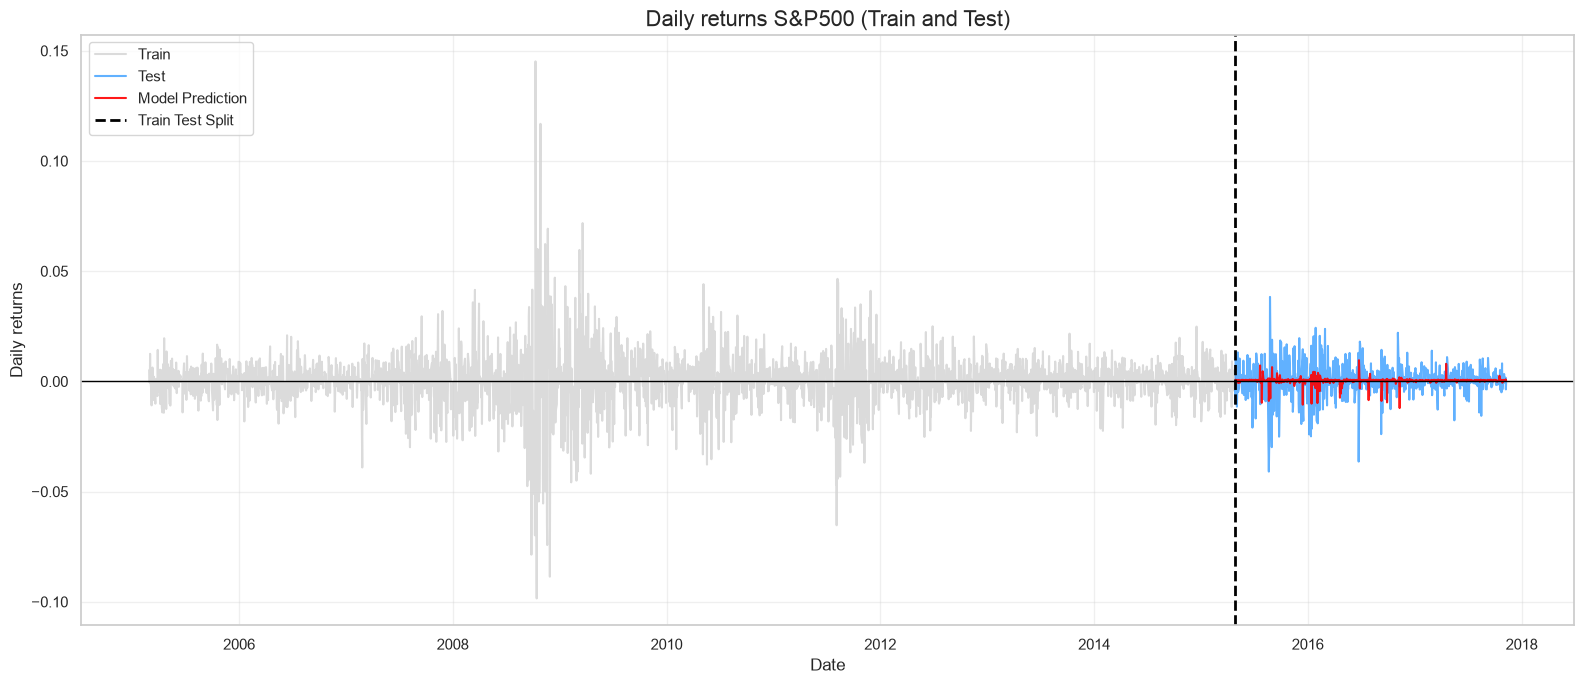

In [16]:
plt.figure(figsize=(16, 7))
plt.plot(y_train.index, y_train, label='Train', color='lightgray', alpha=0.8)
plt.plot(y_test.index, y_test, label='Test', color='dodgerblue', alpha=0.7)
plt.plot(y_test.index, y_pred, label='Model Prediction', color='red', alpha=0.9, linewidth=1.5)
plt.axvline(x=y_test.index[0], color='black', linestyle='--', linewidth=2, label='Train Test Split')
plt.axhline(0, color='black', linewidth=1)
plt.title('Daily returns S&P500 (Train and Test)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Daily returns', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Same story as XGBoost — the prediction collapses to the mean. Two different libraries, identical behaviour, no exploitable signal.

## Transformer (sequence model)

Unlike the tree models (which see one day at a time), the Transformer takes a **10-day window** of returns and predicts the next day.
Sequencing the data: each sample is 10 consecutive days of features, with the following day's SPY return as the target.

In [17]:
SEQ_LEN = 10  # number of past days the model sees at once

X_values = X.values
y_values = y.values

# Build sliding windows: each sample = SEQ_LEN consecutive days, target = the day right after the window
X_seq = []
y_seq = []
for i in range(len(X_values) - SEQ_LEN):
    window_X = X_values[i : i + SEQ_LEN]
    target_y = y_values[i + SEQ_LEN]
    X_seq.append(window_X)
    y_seq.append(target_y)

# Force a contiguous float32 array — otherwise torch.tensor() converts element-by-element and is very slow
X_seq = np.asarray(X_seq, dtype=np.float32)
y_seq = np.asarray(y_seq, dtype=np.float32)

# Same time-ordered split as before (no shuffling)
X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq, y_seq,
    test_size=0.2,
    shuffle=False
)

In [18]:
dates_seq = y.index[SEQ_LEN:]  # one date per target in y_seq
_, dates_test_seq = train_test_split(dates_seq, test_size=0.2, shuffle=False)

In [19]:
class StockTransformer(nn.Module):
    """Transformer encoder for sequence regression.

    Takes a window of SEQ_LEN days (each with `num_features` stock returns) and
    predicts a single value — the next-day SPY return.
    """

    def __init__(self, num_features, seq_len=SEQ_LEN, d_model=64, nhead=4, num_layers=2):
        """
        Args:
            num_features: number of input features per day (here: 12 stocks).
            seq_len: length of the input window (number of past days).
            d_model: internal embedding dimension.
            nhead: number of attention heads (must divide d_model).
            num_layers: number of stacked encoder layers.
        """
        super(StockTransformer, self).__init__()

        # Project the raw features of each day up to the model's embedding dimension
        self.input_layer = nn.Linear(num_features, d_model)

        # Learned positional encoding: without it, attention is order-agnostic and the
        # model couldn't tell day 1 from day 10 — essential for time-series data
        self.pos_embedding = nn.Parameter(torch.zeros(1, seq_len, d_model))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            batch_first=True,
            dim_feedforward=128,
            dropout=0.1
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Map the encoded sequence to a single regression output
        self.output_layer = nn.Linear(d_model, 1)

    def forward(self, x):
        """Run one forward pass; returns the predicted next-day return per sample."""
        x = self.input_layer(x)
        x = x + self.pos_embedding          # inject day-order information
        x = self.transformer_encoder(x)
        x = x[:, -1, :]                     # use the last day's representation as the summary
        out = self.output_layer(x)
        return out.squeeze()


num_features = X_train_seq.shape[2]
model = StockTransformer(num_features=num_features)
print(model)

StockTransformer(
  (input_layer): Linear(in_features=12, out_features=64, bias=True)
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (output_layer): Linear(in_features=64, out_features=1, bias=True)
)


In [20]:
# StandardScaler works on 2D data, but our sequences are 3D (samples, days, features).
# Flatten to 2D, scale, then reshape back to the original 3D shape.
BATCH_SIZE = 32
y_train_t = torch.tensor(y_train_seq, dtype=torch.float32)
y_test_t = torch.tensor(y_test_seq, dtype=torch.float32)

samples_train, seq_len, features = X_train_seq.shape
X_train_2d = X_train_seq.reshape(-1, features)

samples_test, _, _ = X_test_seq.shape
X_test_2d = X_test_seq.reshape(-1, features)

# Fit on train only, apply to test — prevents test-set information leaking into scaling
scaler = StandardScaler()
X_train_scaled_2d = scaler.fit_transform(X_train_2d)
X_test_scaled_2d = scaler.transform(X_test_2d)

# Restore the (samples, days, features) shape the Transformer expects
X_train_seq_scaled = X_train_scaled_2d.reshape(samples_train, seq_len, features)
X_test_seq_scaled = X_test_scaled_2d.reshape(samples_test, seq_len, features)

X_train_t = torch.tensor(X_train_seq_scaled, dtype=torch.float32)
X_test_t = torch.tensor(X_test_seq_scaled, dtype=torch.float32)

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)

test_dataset = TensorDataset(X_test_t, y_test_t)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [21]:
model = StockTransformer(num_features=features)

# L1Loss = MAE, the same metric we evaluate on, so the model optimizes exactly what we measure
criterion = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

EPOCHS = 200

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()              # reset gradients from the previous step
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()                    # compute gradients
        optimizer.step()                   # update weights
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch + 1}/{EPOCHS}] | Average Training Loss: {avg_loss:.6f}")

Epoch [1/200] | Average Training Loss: 0.177487
Epoch [10/200] | Average Training Loss: 0.039289
Epoch [20/200] | Average Training Loss: 0.019604
Epoch [30/200] | Average Training Loss: 0.013980
Epoch [40/200] | Average Training Loss: 0.011330
Epoch [50/200] | Average Training Loss: 0.010073
Epoch [60/200] | Average Training Loss: 0.009852
Epoch [70/200] | Average Training Loss: 0.009130
Epoch [80/200] | Average Training Loss: 0.008877
Epoch [90/200] | Average Training Loss: 0.008939
Epoch [100/200] | Average Training Loss: 0.008573
Epoch [110/200] | Average Training Loss: 0.008251
Epoch [120/200] | Average Training Loss: 0.007784
Epoch [130/200] | Average Training Loss: 0.007855
Epoch [140/200] | Average Training Loss: 0.007518
Epoch [150/200] | Average Training Loss: 0.007466
Epoch [160/200] | Average Training Loss: 0.007344
Epoch [170/200] | Average Training Loss: 0.007495
Epoch [180/200] | Average Training Loss: 0.007187
Epoch [190/200] | Average Training Loss: 0.007056
Epoch [200/

In [22]:
model.eval()
all_preds, all_true = [], []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        all_preds.extend(model(batch_X).numpy())
        all_true.extend(batch_y.numpy())

# True per-sample MAE (not an average of per-batch averages, which the uneven last batch would skew)
test_mae = mean_absolute_error(all_true, all_preds)
baseline_mae = mean_absolute_error(all_true, np.zeros_like(all_true))

print(f"Transformer Test MAE:  {test_mae:.6f}  |  baseline(zero): {baseline_mae:.6f}  |  improvement: {baseline_mae - test_mae:+.6f}")

Transformer Test MAE:  0.005718  |  baseline(zero): 0.005125  |  improvement: -0.000594


Transformer MAE:  0.005718
Baseline MAE:     0.005125
Improvement:      -0.000594


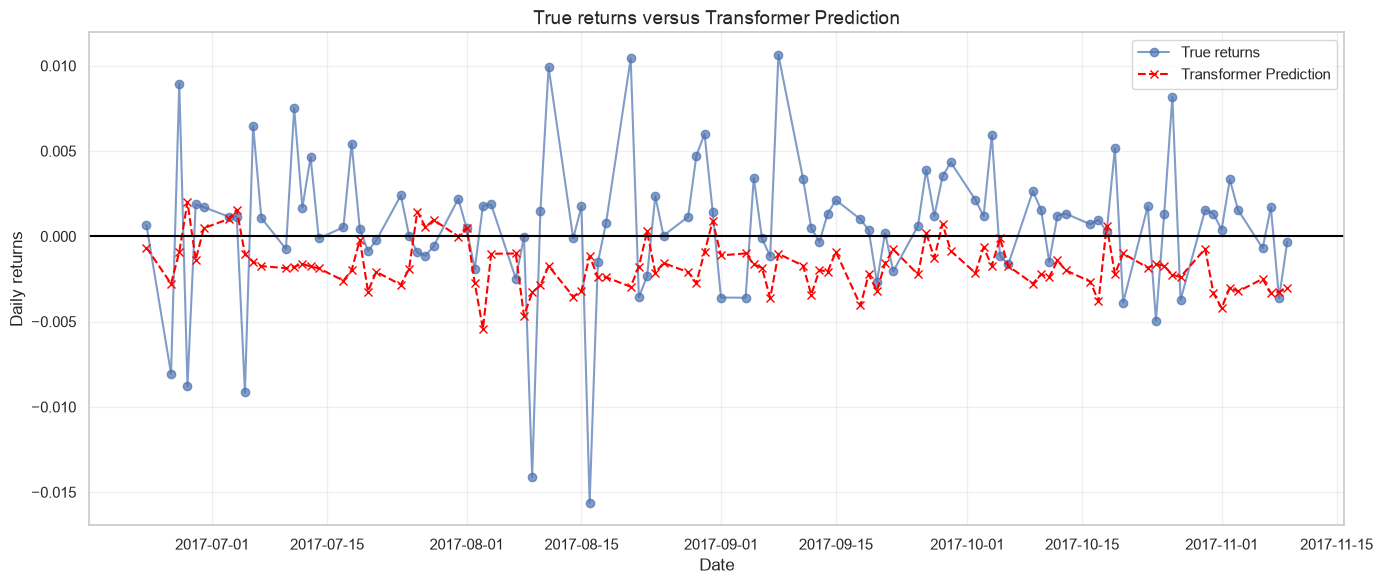

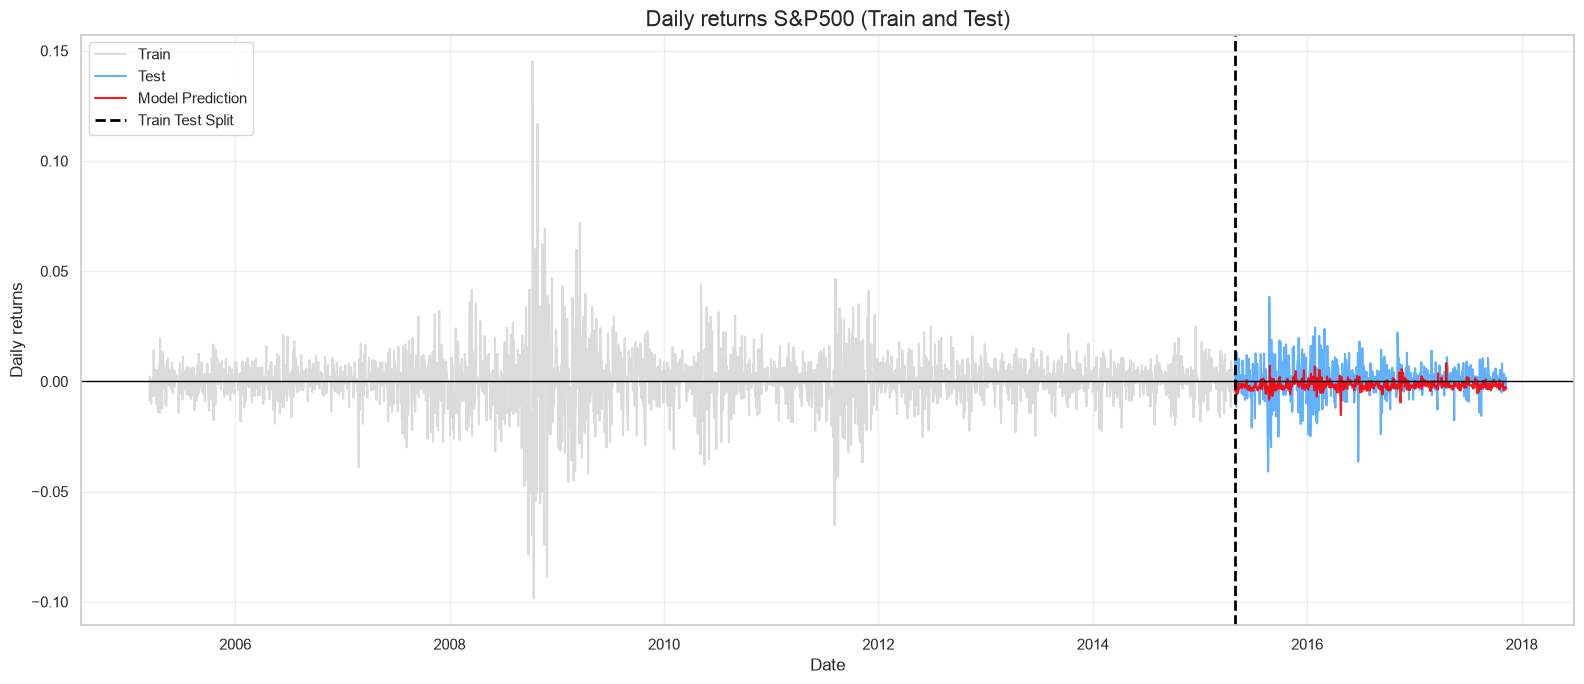

In [23]:
model.eval()
all_predictions = []
all_actuals = []

# Collect predictions over the whole test set, then compute MAE once (per-sample, not per-batch)
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        preds = model(batch_X)
        all_predictions.extend(preds.numpy())
        all_actuals.extend(batch_y.numpy())

all_predictions = np.array(all_predictions)
all_actuals = np.array(all_actuals)

mae_transformer = mean_absolute_error(all_actuals, all_predictions)
mae_baseline_seq = mean_absolute_error(all_actuals, np.zeros_like(all_actuals))

print(f"Transformer MAE:  {mae_transformer:.6f}")
print(f"Baseline MAE:     {mae_baseline_seq:.6f}")
print(f"Improvement:      {mae_baseline_seq - mae_transformer:+.6f}")

# Plot 1 — last 100 test days: prediction vs reality
plt.figure(figsize=(14, 6))
last_days = 100
plt.plot(dates_test_seq[-last_days:], all_actuals[-last_days:],
         label='True returns', marker='o', alpha=0.7)
plt.plot(dates_test_seq[-last_days:], all_predictions[-last_days:],
         label='Transformer Prediction', marker='x', linestyle='--', color='red')
plt.title('True returns versus Transformer Prediction', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Daily returns', fontsize=12)
plt.axhline(0, color='black', linewidth=1.5, linestyle='-')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2 — full train + test view with the split marked
train_dates_seq = y.index[SEQ_LEN: SEQ_LEN + len(y_train_seq)]
plt.figure(figsize=(16, 7))
plt.plot(train_dates_seq, y_train_seq, label='Train', color='lightgray', alpha=0.8)
plt.plot(dates_test_seq, all_actuals, label='Test', color='dodgerblue', alpha=0.7)
plt.plot(dates_test_seq, all_predictions, label='Model Prediction', color='red', alpha=0.9, linewidth=1.5)
plt.axvline(x=dates_test_seq[0], color='black', linestyle='--', linewidth=2, label='Train Test Split')
plt.axhline(0, color='black', linewidth=1)
plt.title('Daily returns S&P500 (Train and Test)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Daily returns', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The Transformer's prediction (red) moves but doesn't track the true returns — movement without direction. That's why its MAE is worse than the flat zero-baseline.

### Transformer — walk-forward

The same 5-fold walk-forward used for the tree models, so all three are evaluated on equal footing.
Scaling and sequence-building happen **inside each fold** (fit on that fold's training part only) to avoid leakage across folds.

In [24]:
SEQ_LEN = 10
EPOCHS = 15      # fewer epochs than the single-split run: this trains 5 models, one per fold
BATCH_SIZE = 32

tf_mae, tf_base = [], []
for fold, (tr, te) in enumerate(tscv.split(X_all), start=1):
    # Scaler fit on this fold's training data only, then applied to its test part (no leakage)
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_all[tr])
    X_te_s = scaler.transform(X_all[te])
    y_tr_raw, y_te_raw = y_all[tr], y_all[te]

    def make_seq(Xv, yv):
        """Turn a 2D returns array into (window, next-day-target) pairs of length SEQ_LEN."""
        Xs, ys = [], []
        for i in range(len(Xv) - SEQ_LEN):
            Xs.append(Xv[i:i+SEQ_LEN]); ys.append(yv[i+SEQ_LEN])
        return np.asarray(Xs, dtype=np.float32), np.asarray(ys, dtype=np.float32)

    X_tr_seq, y_tr_seq = make_seq(X_tr_s, y_tr_raw)
    X_te_seq, y_te_seq = make_seq(X_te_s, y_te_raw)

    loader = DataLoader(TensorDataset(
        torch.tensor(X_tr_seq), torch.tensor(y_tr_seq)), batch_size=BATCH_SIZE, shuffle=False)

    # Fresh model each fold — otherwise it would carry over learning from earlier periods
    model = StockTransformer(num_features=X_tr_seq.shape[2])
    criterion = nn.L1Loss()
    optimizer = optim.Adam(model.parameters(), lr=0.0001)
    model.train()
    for _ in range(EPOCHS):
        for bx, by in loader:
            optimizer.zero_grad()
            loss = criterion(model(bx).reshape(-1), by.reshape(-1))
            loss.backward(); optimizer.step()

    model.eval()
    with torch.no_grad():
        preds = model(torch.tensor(X_te_seq)).reshape(-1).numpy()

    mae = mean_absolute_error(y_te_seq, preds)
    base = mean_absolute_error(y_te_seq, np.zeros_like(y_te_seq))
    tf_mae.append(mae); tf_base.append(base)
    print(f"Fold {fold}:  MAE={mae:.6f}  |  baseline={base:.6f}  |  improvement={base - mae:+.6f}")

print(f"\nTransformer walk-forward:  mean MAE={np.mean(tf_mae):.6f}  mean improvement={np.mean(tf_base) - np.mean(tf_mae):+.6f}")

Fold 1:  MAE=0.066482  |  baseline=0.013818  |  improvement=-0.052664
Fold 2:  MAE=0.026974  |  baseline=0.007338  |  improvement=-0.019636
Fold 3:  MAE=0.020938  |  baseline=0.007502  |  improvement=-0.013437
Fold 4:  MAE=0.010563  |  baseline=0.005630  |  improvement=-0.004933
Fold 5:  MAE=0.008121  |  baseline=0.004649  |  improvement=-0.003471

Transformer walk-forward:  mean MAE=0.026616  mean improvement=-0.018828


## Conclusion

Across all three models and a 5-fold walk-forward, **none beats the trivial zero-baseline** — improvements are at or below zero everywhere.
The trees collapse to the mean; the Transformer adds movement but no direction, ending up even worse.
Tuning (see the classification notebook) doesn't change this: the limitation is the data, not the models. Daily SPY returns are not predictable from same-day constituent returns — consistent with weak-form market efficiency.